In [24]:
# Импорт библиотек
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
# Загрузка данных
data = pd.read_csv('data.csv')

In [5]:
# Базовый обзор датасета
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       500 non-null    int64  
 1   Priority                 500 non-null    int64  
 2   Systems                  500 non-null    int64  
 3   Integrations             500 non-null    int64  
 4   Enterprise architecture  500 non-null    str    
 5   Technical debt           500 non-null    bool   
 6   PM                       490 non-null    str    
 7   Days                     500 non-null    int64  
 8   Effort                   5 non-null      float64
dtypes: bool(1), float64(1), int64(5), str(2)
memory usage: 27.9 KB


In [29]:
# Первые 5 строк для понимания данных в колонках
'''
Сразу видно категориальные переменные
'Enterprise architecture', 'Technical debt', 'PM'
И числовые
'Priority', 'Systems', 'Integrations'
'''
data.head()

,Priority,Systems,Integrations,Enterprise architecture,Technical debt,PM,Days
0,2,1,1,in progress,False,Andrei H,153
1,2,2,6,in progress,True,Elena A,186
2,1,2,2,in progress,True,Ksenia G,107
3,2,3,7,new,False,Andrei H,186
4,1,2,6,done,False,Ksenia G,92


In [10]:
# Поле Id не несет в себе полезной нагрузки и выглядит избыточным - удаляю
data = data.drop('Id', axis = 1)

In [11]:
# Проверяю удаление
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Priority                 500 non-null    int64  
 1   Systems                  500 non-null    int64  
 2   Integrations             500 non-null    int64  
 3   Enterprise architecture  500 non-null    str    
 4   Technical debt           500 non-null    bool   
 5   PM                       490 non-null    str    
 6   Days                     500 non-null    int64  
 7   Effort                   5 non-null      float64
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 24.0 KB


In [12]:
# Ищу пропуски в данных
data.isnull().sum()

Priority                     0
Systems                      0
Integrations                 0
Enterprise architecture      0
Technical debt               0
PM                          10
Days                         0
Effort                     495
dtype: int64

In [13]:
# Поле Effort имеет 99% пропусков и в таком виде ничем не помогает - удаляю
data = data.drop('Effort', axis = 1)

In [14]:
# Проверяю удаление
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Priority                 500 non-null    int64
 1   Systems                  500 non-null    int64
 2   Integrations             500 non-null    int64
 3   Enterprise architecture  500 non-null    str  
 4   Technical debt           500 non-null    bool 
 5   PM                       490 non-null    str  
 6   Days                     500 non-null    int64
dtypes: bool(1), int64(4), str(2)
memory usage: 20.1 KB


In [15]:
# Обратил внимание на пропуски в поле PM
# Считаю частоту по каждому из PM
pm_counts = data['PM'].value_counts(dropna=False)
print("\nРаспределение PM:")
print(pm_counts)


Распределение PM:
PM
Elena A     166
Andrei H    147
Andrei M     89
Ksenia G     88
NaN          10
Name: count, dtype: int64


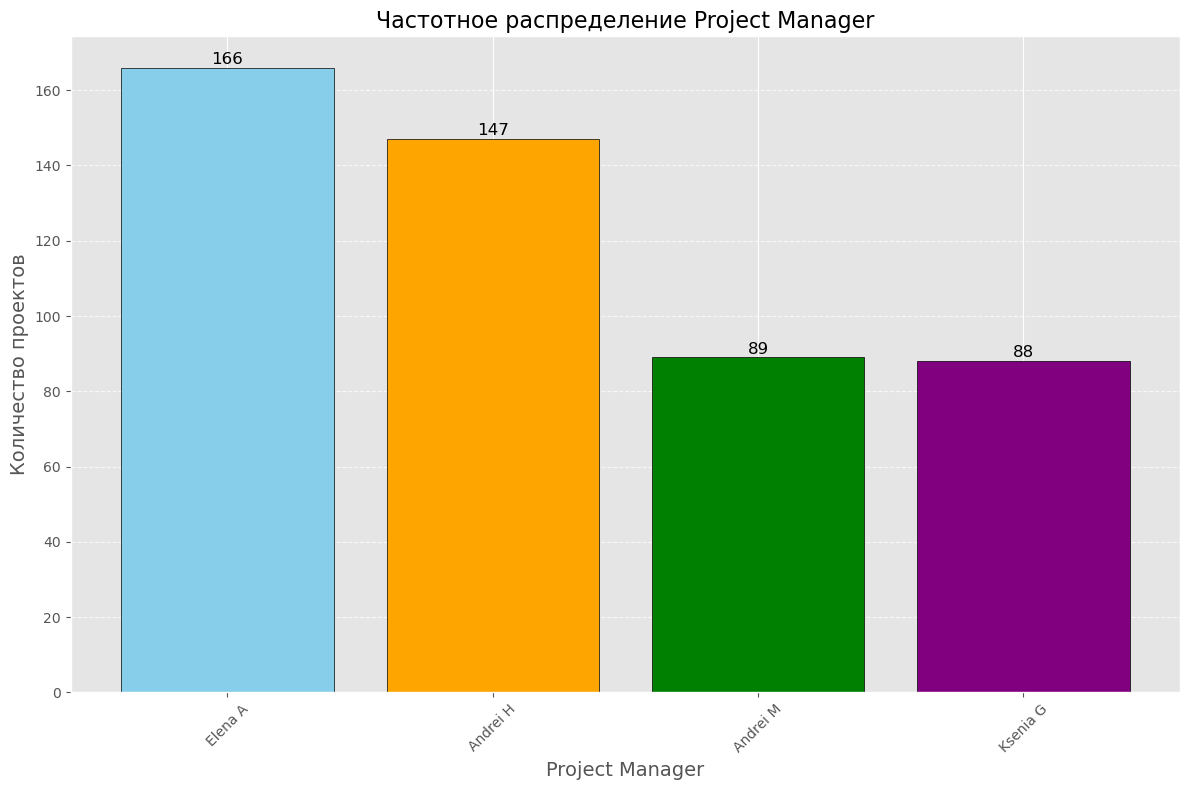

In [16]:
# Визуализация распределения
pm_counts = data['PM'].value_counts()
plt.figure(figsize=(12, 8))
plt.style.use('ggplot')

plt.bar(
    pm_counts.index,
    pm_counts.values,
    color=['skyblue', 'orange', 'green', 'purple'],
    edgecolor='black'
)

plt.title('Частотное распределение Project Manager', fontsize=16)
plt.xlabel('Project Manager', fontsize=14)
plt.ylabel('Количество проектов', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(pm_counts.values):
    plt.text(i, value + 1, str(value), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
'''
В данных по PM процент пропусков минимальный,
считаю допустимым заполнить пропуски значением Elena A 
с учетом наиболее частого участия этого PM в проектах
'''
data['PM'] = data['PM'].fillna('Elena A')
# Перепроверяю - теперь пропусков нигде нет
data.isnull().sum()

Priority                   0
Systems                    0
Integrations               0
Enterprise architecture    0
Technical debt             0
PM                         0
Days                       0
dtype: int64

In [19]:
# Статистический обзор числовых признаков
data.describe()

,Priority,Systems,Integrations,Days
count,500.000000,500.00000,500.000000,500.000000
mean,1.742000,2.57600,5.034000,179.612000
std,0.785283,0.92625,2.874956,94.178728
min,1.000000,1.00000,1.000000,74.000000
25%,1.000000,2.00000,3.000000,101.000000
50%,2.000000,3.00000,5.000000,169.000000
75%,2.000000,3.00000,7.000000,205.000000
max,3.000000,5.00000,12.000000,365.000000


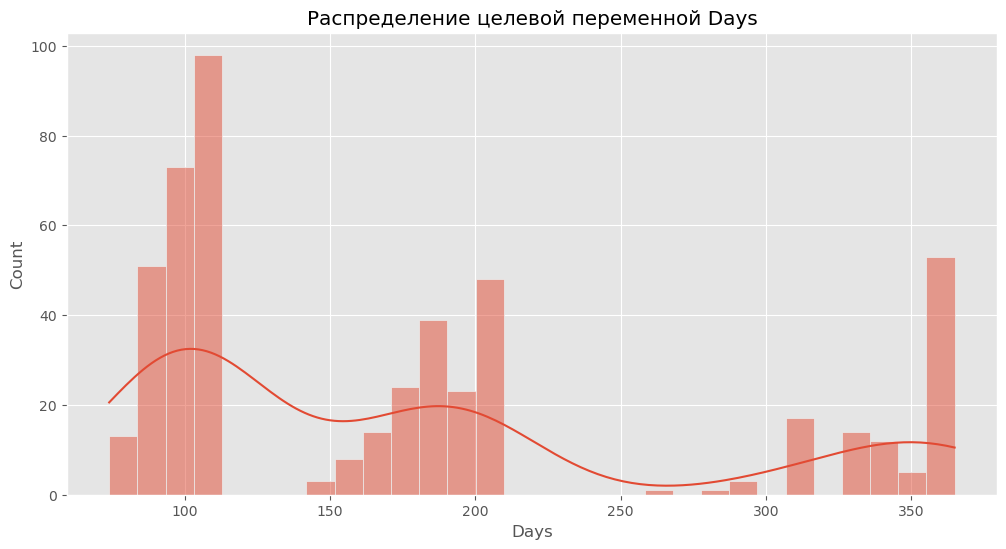

In [27]:
# Целевая переменная - Days - Визуализация распределения
'''
Однозначно видно разделение на 3 группы - предполагаю, что это связано
с 3-мя возможными Priority у проектов
'''
plt.figure(figsize=(12,6))
sns.histplot(data['Days'], bins=30, kde=True)
plt.title('Распределение целевой переменной Days')
plt.show()

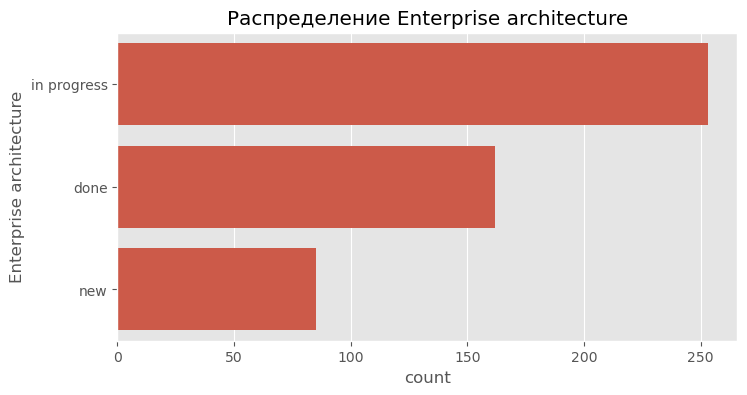

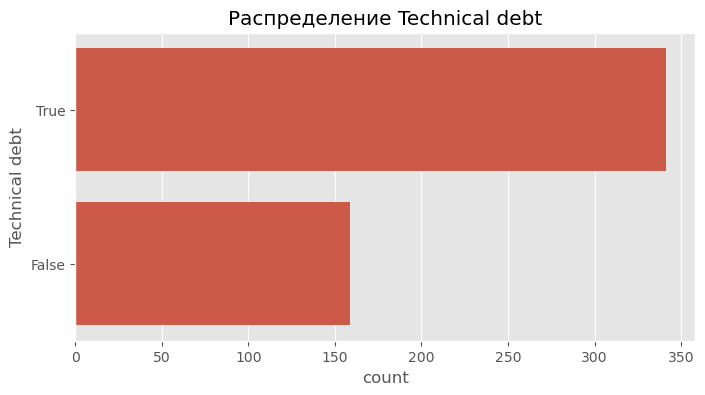

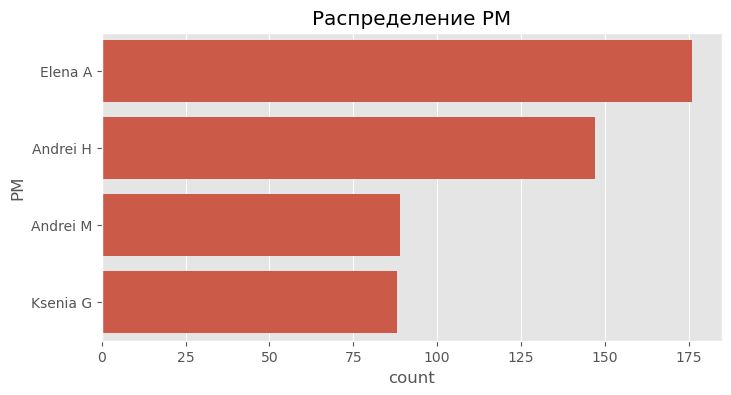

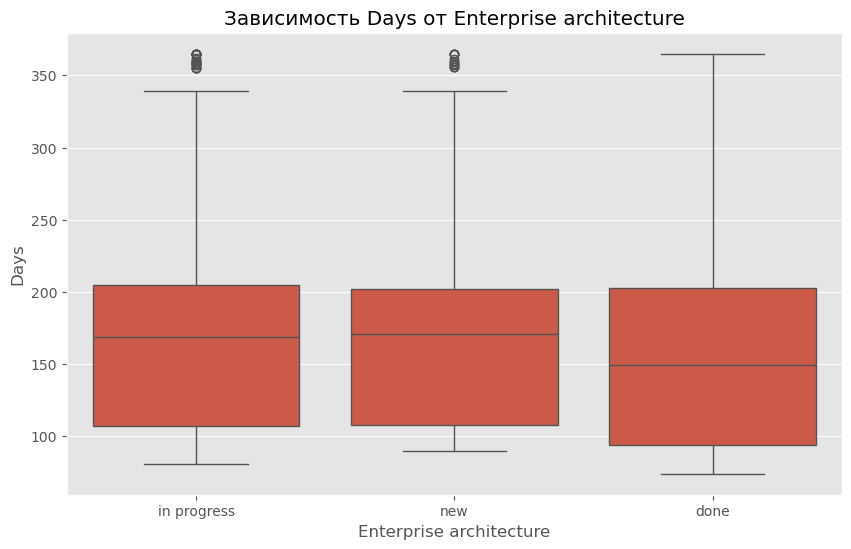

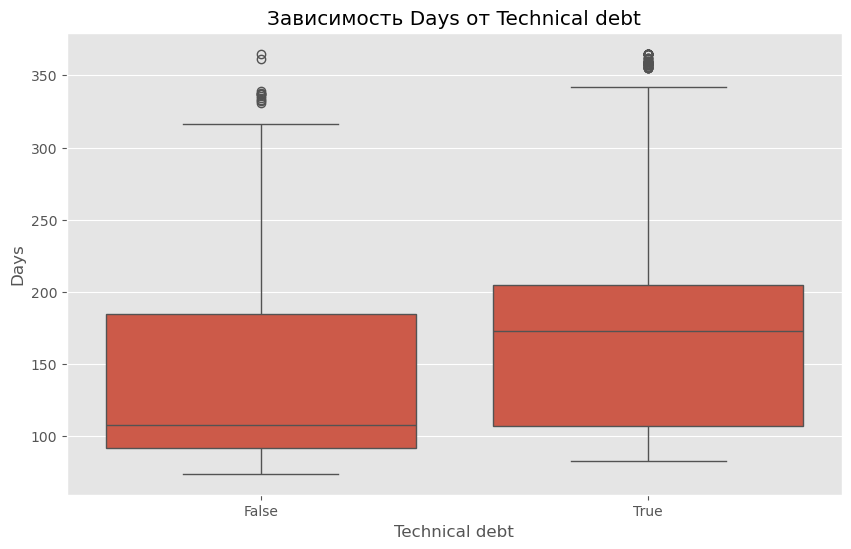

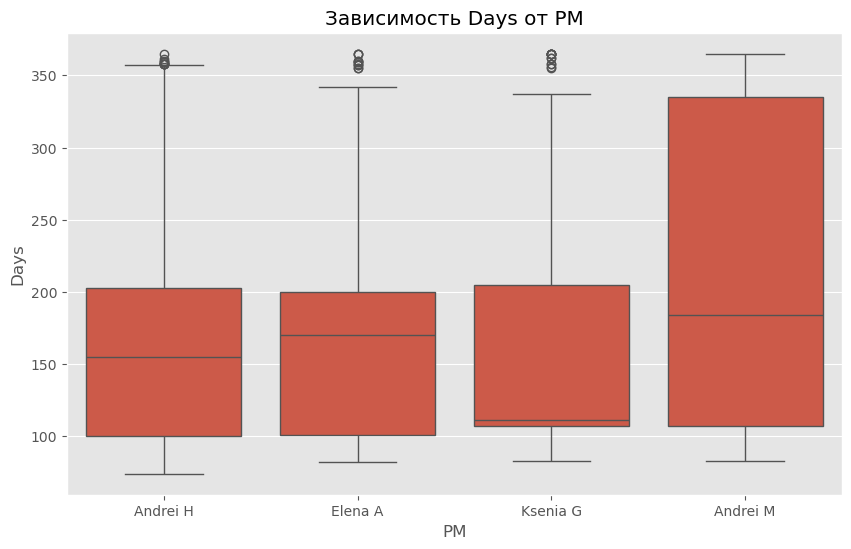

In [28]:
# Анализ категориальных переменных
'''
Enterprise architecture
больше всего проектов, которые поступают с находящейся в проработке EA,
меньше всего проектов, где EA еще не начата

Technical debt
больше всего проектов, где требуется работа с Техническим долгом

PM
больше всего проектов ведет Elena А,
с некоторым отставанием Andrei H,
а Andrei M и Ksenia G - ведут одинаково меньше в 2 раза проектов, чем Elena A 
'''
categorical_cols = ['Enterprise architecture', 'Technical debt', 'PM']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=data[col], order=data[col].value_counts().index)
    plt.title(f'Распределение {col}')
    plt.show()

# Взаимосвязь категориальных переменных с Days
'''
Enterprise architecture
Для проектов с финализированной EA медианная длительность реализации меньше (быстрее),
чем у проектов с неначатой или незавершенной ЕА.
Но при этом, основная часть проектов по верхнему и нижнему квантилю для всей стадий ЕА
находится примерно в одном уровне.

Technical debt
Медианная зависимость количества дней на реализацию от технического долга более явная
и доходит до +60 дней при необходимости работы с техдолгом.

PM
Однозначно видно отличие Andrei M при сравнении по верхнему квантилю,
даже при условии одинакового количества проектов с Ksenia G.
Если же рассматривать медианную зависимость - Ksenia G имеет лучший показатель
'''
for col in categorical_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=data[col], y=data['Days'])
    plt.title(f'Зависимость Days от {col}')
    plt.show()

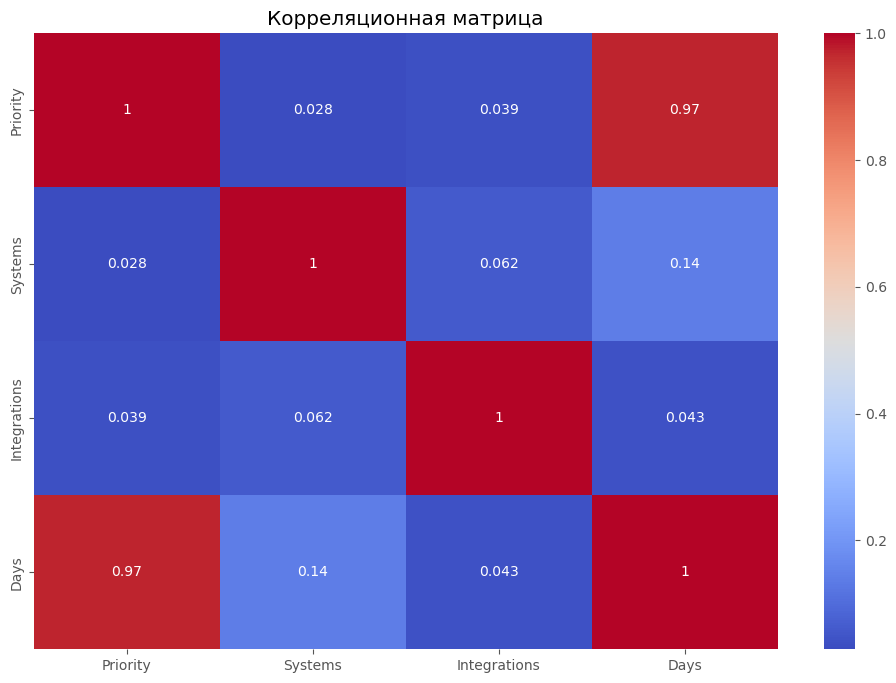

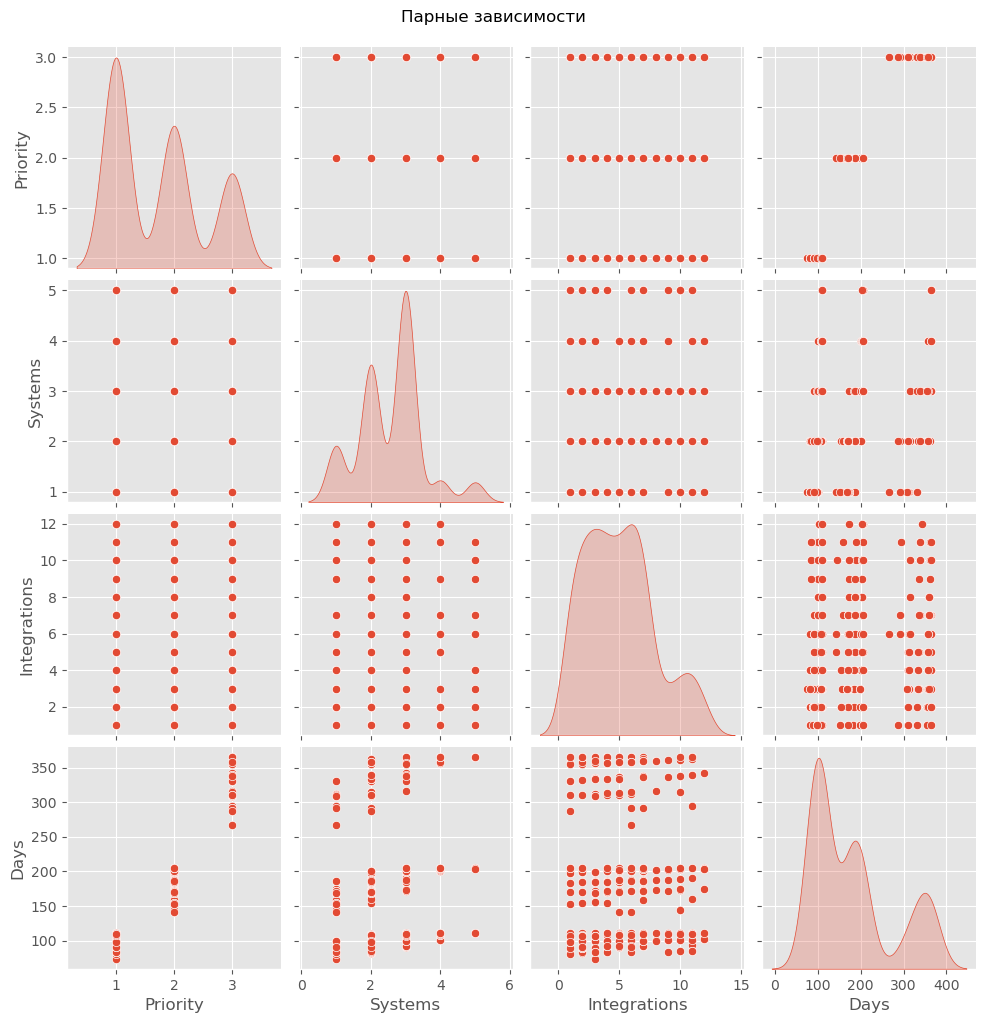

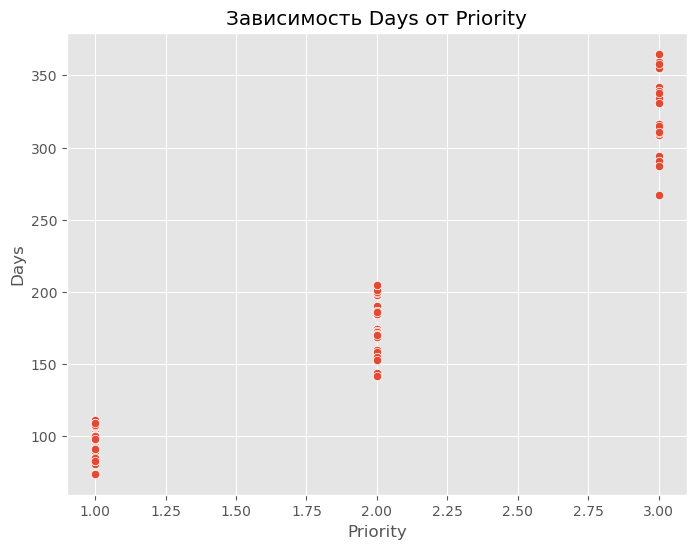

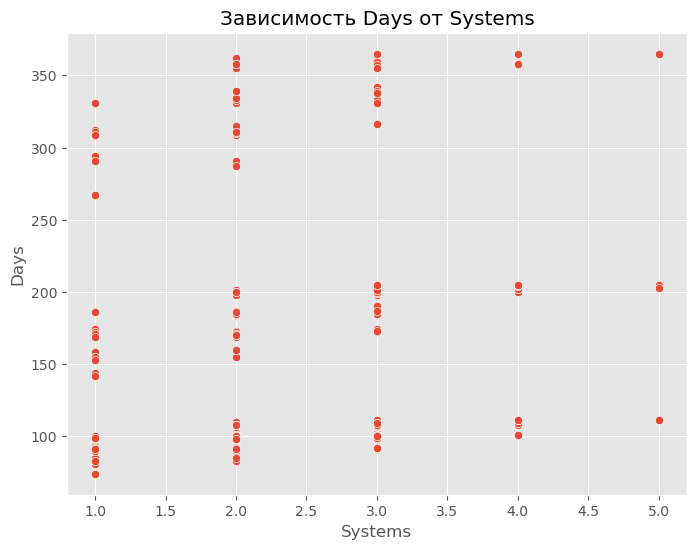

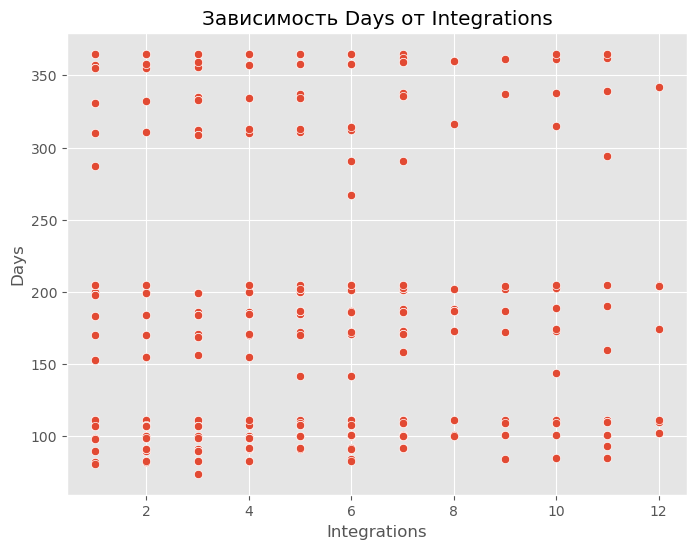

In [31]:
# Анализ числовых переменных
'''
Из корреляционной матрицы можно сделать вывод, что
сильнее всего на длительность проекта влияет его приоритет,
далее - количество систем и интеграций.

На графиках зависимости целевой переменной от числовых признаков
подтверждается зависимость от приоритета - чем ниже приоритет, тем дольше срок.
'''
numeric_cols = ['Priority', 'Systems', 'Integrations']

plt.figure(figsize=(12,8))
sns.heatmap(data[numeric_cols + ['Days']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

# Парные графики
sns.pairplot(data[numeric_cols + ['Days']], diag_kind='kde')
plt.suptitle('Парные зависимости', y=1.02)
plt.show()

# Анализ взаимосвязей между числовыми признаками и Days
for col in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=data[col], y=data['Days'])
    plt.title(f'Зависимость Days от {col}')
    plt.show()